### Очистка и нормализация фармацевтических реестров стран

### Описание проекта

В рамках проекта выполнена унификация и очистка фармацевтических реестров
трёх стран: Уганда, Алжир и Саудовская Аравия.

Исходные данные содержали:
- различные структуры колонок
- мультиязычные значения (английский / французский)
- дубликаты компаний
- вариации написания действующих веществ
- пропущенные ATC-коды
- заглушки и аномалии

### Цель проекта

Создать единый стандартизированный датасет, готовый для построения дашборда в Datalens

##### 1. Инициализация и загрузка данных
*   Формирование из 3х разрозненных датасетов единого структурированного датасета

##### 2. Очистка от пропусков

 Работа с пропусками
*   Анализ количества пропущенных значений в разрезе столбцов
*   Удаление или заполнение пропусков

  
##### 3. Преобразование типов данных
 
*   Приведение столбцов с датами к формату datetime64, с ценами в numeric
 
*   Поиск и удаление аномалий, проверка корректности данных (временных интервалов, заглушки в данных)


##### 4. Текстовая нормализация
*   Очистка пунктуации и пробелов
  
  **Функция `clean_text`**: удаление лишних знаков препинания, приведение к нижнему регистру и удаление двойных пробелов.

*   Применение функции к колонкам:
    *   `active_ingredient`
    *   `coutry_of_manufacture`
    *   `manufacturer_name`
    *   `distributor_name`
    *   `form`
      
*  Приведение к нижнему регистру смешанных столбцов (где буквы и цифры, знаки препинания несут смысл)
##### 5. Интеллектуальный поиск и замена (Fuzzy Matching)
Функции сопоставления
*   **Функции из библиотеки rapidfuzz**: поиск сходства между текущим значением и эталонным списком.

*   Масштабирование поиска и замены на все ключевые столбцы для унификации названий.

##### 6. Обогащение данных
*   Дополнение отсутствующих АТХ кодов на основе имеющихся данных о МНН (международных непатентованных наименованиях).

##### 7. Сохранение результата
*   Удаление дубликатов и выгрузка очищенного датасета в формат `.csv`.

#### Целевая структура таблицы (drugs)
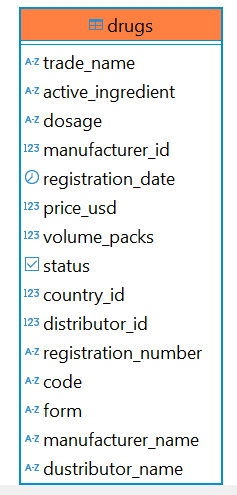

#### 1. Инициализация и загрузка данных
---

In [113]:
import pandas as pd
import numpy as np
from rapidfuzz import process, fuzz 
from tqdm import tqdm

In [114]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

---
Каждый реестр имеет собственные названия колонок.
Для объединения используются словари сопоставления.

---

In [115]:
dfs=[]
path='countries\\'
table_names=['Uganda.csv','Algeria.csv','Saudi.csv'] 
for t in table_names:
    df=pd.read_csv(path+t, sep=';')
    df['Country']=t.replace('.csv','')
    dfs.append(df)

In [116]:
target_columns = [
    'trade_name',
    'active_ingredient',
    'dosage',
    'manufacturer_id',
    'registration_date',
    'price_usd',
    'volume_packs',
    'status',
    'country_id',
    'distributor_id',
    'registration_number',
    'code',
    'form',
    'manufacturer_name',
    'distributor_name',
    'country_of_manufacture',
    'pack_size',
    'country'
]

In [117]:
for df in dfs:
    print(f'Страна {df['Country'].iloc[1]}: \n колонки {df.columns.tolist()}\n')

Страна Uganda: 
 колонки ['NDA REGISTRATION NUMBER', 'LICENSE HOLDER', 'LOCAL TECHNICAL REPRESENTATIVE', 'NAME OF DRUG', 'GENERIC NAME OF DRUG', 'STRENGTH OF DRUG', 'MANUFACTURING SITE', 'COUNTRY OF MANUFACTURE', 'DOSAGE FORM', 'PACK SIZE', 'REGISTRATION DATE', 'Country']

Страна Algeria: 
 колонки ['N', 'N°ENREGISTREMENT', 'CODE', 'DENOMINATION COMMUNE INTERNATIONALE', 'NOM DE MARQUE', 'FORME', 'DOSAGE', 'CONDITIONNEMENT', 'LISTE', 'P1', 'P2', 'OBS', "LABORATOIRES DETENTEUR DE LA DECISION D'ENREGISTREMENT", "PAYS DU LABORATOIRE DETENTEUR DE LA DECISION D'ENREGISTREMENT", 'date_initial', 'registration_date_final', 'TYPE', 'STATUT', 'DUREE DE STABILITE', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Country']

Страна Saudi: 
 колонки ['ATC Code1', 'ATC Code2', 'Authorization Status', 'Country of marketing company', 'Description Code', 'Distribution Site', 'Dosage Form', 'First agent', 'Legal Status', 'Manufacturer Country', 'Manufacturer Name', 'Marketing Company', 'Marketing Status', '

In [118]:
mapping_uganda = {
    'NDA REGISTRATION NUMBER': 'registration_number',
    'LICENSE HOLDER':'manufacturer_name',
    'LOCAL TECHNICAL REPRESENTATIVE':'distributor_name',
    'NAME OF DRUG':'trade_name',
    'GENERIC NAME OF DRUG':'active_ingredient',
    'STRENGTH OF DRUG':'dosage',
    'COUNTRY OF MANUFACTURE':'country_of_manufacture',
    'DOSAGE FORM':'form',
    'PACK SIZE':'pack_size',
    'REGISTRATION DATE':'registration_date',
    'Country':'country'
}

In [119]:
mapping_algeria = {
    'N°ENREGISTREMENT':'registration_number',
    'DENOMINATION COMMUNE INTERNATIONALE':'active_ingredient',
    'NOM DE MARQUE':'trade_name', 
    'FORME':'form',
    'DOSAGE':'dosage',
    'LABORATOIRES DETENTEUR DE LA DECISION D\'ENREGISTREMENT':'manufacturer_name',
    'PAYS DU LABORATOIRE DETENTEUR DE LA DECISION D\'ENREGISTREMENT':'country_of_manufacture',
    'registration_date_final':'registration_date',
    'Country':'country'
}

In [120]:
mapping_saudi = {
    'ATC Code2':'code', 
       'Dosage Form':'form', 
    'First agent':'distributor_name',
    'Manufacturer Country':'country_of_manufacture',
    'Manufacturer Name':'manufacturer_name',  
    'Price':'price_usd',
       'Register Number':'registration_number',
    'Scientific Name':'active_ingredient',
   'Trade Name':'trade_name',
       'dosage':'dosage', 
    'Country':'country',
    'Package':'pack_size'
}

In [121]:
#Для удобства объединим столбцы в df Uganda
dfs[2]['Package'] = df[['Package Size', 'Package Type']].astype(str).agg(' '.join, axis=1)

In [122]:
mappings={
    'uganda':mapping_uganda,
    'algeria':mapping_algeria,
    'saudi':mapping_saudi
}
dfs_new=[]
dfs_tuple=[(dfs[0],'uganda'),( dfs[1], 'algeria'), (dfs[2], 'saudi')]
for df, country in dfs_tuple:
    df = df.rename(columns=mappings.get(country, {}))
    existing_cols = [c for c in target_columns if c in df.columns]
    dfs_new.append(df[existing_cols])

final_df = pd.concat(dfs_new, ignore_index=True)

In [123]:
print(f"Общее количество строк после объединения: {len(final_df)}")

Общее количество строк после объединения: 18740


---
#### ✅ Результат объединения: `final_df`, всего строк 18740

---

#### 2. Очистка от пропусков и аномалий
 2.1. Работа с пропусками

In [124]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18740 entries, 0 to 18739
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   trade_name              18285 non-null  object 
 1   active_ingredient       18283 non-null  object 
 2   dosage                  18238 non-null  object 
 3   registration_date       9549 non-null   object 
 4   registration_number     18288 non-null  object 
 5   form                    18284 non-null  object 
 6   manufacturer_name       18283 non-null  object 
 7   distributor_name        13286 non-null  object 
 8   country_of_manufacture  18284 non-null  object 
 9   pack_size               13357 non-null  object 
 10  country                 18740 non-null  object 
 11  price_usd               8650 non-null   float64
 12  code                    8609 non-null   object 
dtypes: float64(1), object(12)
memory usage: 1.9+ MB


In [125]:
missing_cols = set(target_columns) - set(final_df.columns)
missing_cols

{'country_id', 'distributor_id', 'manufacturer_id', 'status', 'volume_packs'}

---
Всего строк 18740, есть пропуски, вероятно связаны с отсутствием данных в начальных датафреймах до объединения. Для нас ключевые столбцы `trade_name`,`active_ingredient`, `manufacturer_name`, `distributor_name`, `country_of_manufacture`,  `pack_size`, `country`, `code`     

Столбцов данных по столбцам `country_id`, `distributor_id`, `manufacturer_id`, `status`, `volume_packs` не оказалось ни в одном из датафреймов, пока их не будем добавлять в датафрейм, так как они больше нужны для нормализации БД. На данном этапе не так актуально, т.к. строк датафрейма не много.

---

In [126]:
final_df[final_df[['active_ingredient', 'trade_name']].isna().all(axis=1)]

,trade_name,active_ingredient,dosage,registration_date,registration_number,form,manufacturer_name,distributor_name,country_of_manufacture,pack_size,country,price_usd,code
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Uganda,NaN,NaN
31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Uganda,NaN,NaN
197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Uganda,NaN,NaN
204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Uganda,NaN,NaN
207,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Uganda,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Uganda,NaN,NaN
10085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Algeria,NaN,NaN
10086,NaN,NaN,NaN,NaN,F=Fabriqué localement,NaN,NaN,NaN,NaN,NaN,Algeria,NaN,NaN
10087,NaN,NaN,NaN,NaN,I=Importé,NaN,NaN,NaN,NaN,NaN,Algeria,NaN,NaN


In [127]:
df_clean=final_df.dropna(subset=['active_ingredient', 'trade_name']).copy()

In [128]:
df_clean[df_clean[['manufacturer_name', 'country_of_manufacture']].isna().any(axis=1)]

,trade_name,active_ingredient,dosage,registration_date,registration_number,form,manufacturer_name,distributor_name,country_of_manufacture,pack_size,country,price_usd,code
1433,FIBGAL 145,FENOFIBRATE,145 MG,12/18/2024,NDA/MAL/HDP/11729,ORAL SOLID ORDINARY FILM-COATED TABLETS,AUROBINDO PHARMA LIMITED,PHILLIPS PHARMACEUTICALS (UGANDA) LIMITED,NaN,1.0X10.0X10.0 TABLET BLISTER,Uganda,NaN,NaN
2297,ACICONE-S ORAL SUSPENSION,MAGALDRATE + SIMETHICONE,540MG/5ML + 40MG/5ML,01.07.2006,NaN,ORAL LIQUID ORDINARY SUSPENSIONS,NaN,KARURI PHARMACEUTICALS LTD.,EGYPT,1.0X120.0 ML BOTTLE,Uganda,NaN,NaN
18130,Plasma-Lyte 148 (pH 7.4),"SODIUM CHLORIDE,POTASSIUM CHLORIDE,MAGNESIUM C...","5.26,0.37,0.30,3.68,5.02 g/l,",NaN,1703257086,Solution for infusion,NaN,Arabian Health Care Co.,Spain,12 Bag,Saudi,110.90,No value


---
Будем помнить про эти пропуски при текстовой нормализации.

---

In [129]:
deleted_rows_count=100-(len(df_clean)/len(final_df)*100)
print(f'Удалено {deleted_rows_count:.2f}% строк с пустыми значениями в столбце active_ingredient, trade_name из-за отсутствия ключевых полей')

Удалено 2.44% строк с пустыми значениями в столбце active_ingredient, trade_name из-за отсутствия ключевых полей


---
##### 3. Преобразование типов данных
 3.1. Приведение столбцов с датами к формату datetime64, с ценами в numeric

 3.2. Поиск и удаление аномалий, проверка корректности данных (временных интервалов, заглушки в данных)

---

In [130]:
df_clean['registration_date']=pd.to_datetime(df_clean['registration_date'], errors='coerce')
df_clean['price_usd']=pd.to_numeric(df_clean['price_usd'], errors='coerce')

In [131]:
# функция, которая ищет аномалии в столбцах: 
#для числовых и форматов даты это максимальное и минимальное значение
#для текстовых заглушки (---) и текст менее 3х знаков

def search_anomaly(series):
    if pd.api.types.is_numeric_dtype(series) or pd.api.types.is_datetime64_any_dtype(series):
        return f"Min: {series.min()} | Max: {series.max()}"

    else:
        temp_series = series.dropna().astype(str) #убираем пропуски, чтобы len() не выдал ошибку
        short_values = temp_series[temp_series.str.len() < 3] # Находим строки, где длина текста меньше 3 символов
        pattern = r'([^\w\s])\1{2,}' #([^\w\s]) находим любой символ, который не является буквой, цифрой или пробелом (т.е. знаки препинания).
                                        #\1 ищет точно такой же символ, как символ в первой скобке.
                                        #{2,} повтор должен встретиться минимум 2 раза подряд (итого 1 оригинал + 2 повтора = 3 символа).
        repeated_chars = temp_series[temp_series.str.contains(pattern, regex=True)].unique()
        
        return {
            "short": short_values, 
            "repeated_symbols": repeated_chars[:5]
        }

In [132]:
for col in df_clean.columns:
    print(f"Столбец: {col}")
    print(f"{search_anomaly(df_clean[col])}\n")

Столбец: trade_name
{'short': 1722    D5
1724    RL
1800    5D
2233    P2
2843    RL
3009    NS
3509    NS
4059    O2
4060    O2
Name: trade_name, dtype: object, 'repeated_symbols': array([], dtype=object)}

Столбец: active_ingredient
{'short': Series([], Name: active_ingredient, dtype: object), 'repeated_symbols': array([], dtype=object)}

Столбец: dosage
{'short': 342     1G
405     1G
419     1G
544     1G
691     1G
        ..
8510    1G
8511    1G
9011    4%
9193    2G
9194    2G
Name: dosage, Length: 103, dtype: object, 'repeated_symbols': array(['---',
       '100 ml de solution Chlorure de Sodium (NaCl).... 21.48g\nChlorure de Potassium (KCl) ….. 0.522g\n Chlorure de Calcium dihydratE (CaCl₂, 2H₂O) 0.771g\nChlorure de magnEsium hexahydratE (MgCl₂, 6H₂O… 0.712g'],
      dtype=object)}

Столбец: registration_date
Min: 1997-01-07 00:00:00 | Max: 2025-05-06 00:00:00

Столбец: registration_number
{'short': Series([], Name: registration_number, dtype: object), 'repeated_symbols': arr

C:\Users\eshai\AppData\Local\Temp\ipykernel_8816\2932029790.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  repeated_chars = temp_series[temp_series.str.contains(pattern, regex=True)].unique()
C:\Users\eshai\AppData\Local\Temp\ipykernel_8816\2932029790.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  repeated_chars = temp_series[temp_series.str.contains(pattern, regex=True)].unique()
C:\Users\eshai\AppData\Local\Temp\ipykernel_8816\2932029790.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  repeated_chars = temp_series[temp_series.str.contains(pattern, regex=True)].unique()
C:\Users\eshai\AppData\Local\Temp\ipykernel_8816\2932029790.py:15: UserWarning: This pattern is interpreted as a regular expression, and ha

{'short': 12105    3M
Name: manufacturer_name, dtype: object, 'repeated_symbols': array([], dtype=object)}

Столбец: distributor_name
{'short': Series([], Name: distributor_name, dtype: object), 'repeated_symbols': array(['-----'], dtype=object)}

Столбец: country_of_manufacture
{'short': Series([], Name: country_of_manufacture, dtype: object), 'repeated_symbols': array([], dtype=object)}

Столбец: pack_size
{'short': Series([], Name: pack_size, dtype: object), 'repeated_symbols': array([], dtype=object)}

Столбец: country
{'short': Series([], Name: country, dtype: object), 'repeated_symbols': array([], dtype=object)}

Столбец: price_usd
Min: 0.0 | Max: 13236137.05

Столбец: code
{'short': Series([], Name: code, dtype: object), 'repeated_symbols': array([], dtype=object)}



C:\Users\eshai\AppData\Local\Temp\ipykernel_8816\2932029790.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  repeated_chars = temp_series[temp_series.str.contains(pattern, regex=True)].unique()
C:\Users\eshai\AppData\Local\Temp\ipykernel_8816\2932029790.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  repeated_chars = temp_series[temp_series.str.contains(pattern, regex=True)].unique()
C:\Users\eshai\AppData\Local\Temp\ipykernel_8816\2932029790.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  repeated_chars = temp_series[temp_series.str.contains(pattern, regex=True)].unique()
C:\Users\eshai\AppData\Local\Temp\ipykernel_8816\2932029790.py:15: UserWarning: This pattern is interpreted as a regular expression, and ha

---
| Колонка | Проблема | Решение |
| :--- | :--- | :--- |
| **trade_name / dosage** | Короткие коды (D5, 1G, RL) | **Оставить**. Это специфика фармацевтического рынка (сокращения растворов и дозировок). |
| **dosage / form / distributor_name** | 🚩 Символьные заглушки (`---`, `-----`) | **Заменить**. Заменить на `NaN` или `unknown`, чтобы не искажать статистику. |
| **price_usd** | Нулевая цена (`0.0`) | **Заменить на null** |
| **manufacturer_name** | Короткий код | **Оставить**. Есть такая компания |

---


In [133]:
df_clean['price_usd'].describe()

count       8650.00
mean        6480.45
std       199641.25
min            0.00
25%           24.60
50%           66.40
75%          303.48
max     13236137.05
Name: price_usd, dtype: float64

In [134]:
df_clean[df_clean['price_usd']==13236137.05]

,trade_name,active_ingredient,dosage,registration_date,registration_number,form,manufacturer_name,distributor_name,country_of_manufacture,pack_size,country,price_usd,code
18086,Hemgenix,Etranacogene dezaparvovec,"1*10^13 GC,",NaT,3101256786,Concentrate for solution for infusion,UniQure,Cigalah Group,United States,1 Vial,Saudi,13236137.05,No value


Hemgenix правда очень дорогостоящий препарат, не ошибка данных

In [135]:
cols_anomaly=['dosage','form','distributor_name']
for col in cols_anomaly:
    df_clean[col]=df_clean[col].replace(r'^-+$', np.nan, regex=True) #начало строки, один или более дефисов, конец строки

df_clean.loc[df_clean['price_usd']==0, 'price_usd']=np.nan

---
✅ Привела данные к корректным форматам

✅ Почистила строки с аномалиями (0 значение в `price_usd`, заглушки в `dosage`,`form`,`distributor_name` )

---

##### 4. Текстовая нормализация

---

In [136]:
#убираем лишние знаки препинания, пробелы, в тех столбцах, где может быть только текст и иногда цифры(например, 'vitaminb12')
def pre_clean(val):
    if pd.isna(val): # обработка пропусков (чтобы не падало на NaN)
        return ""
    t = str(val).lower()
    clean_chars = [char if char.isalnum() or char.isspace() else ' ' for char in t]
    t = "".join(clean_chars)
    t = " ".join(t.split()).strip()
    return t

In [137]:
target_text_cols = [ 
    'active_ingredient', 
    'country_of_manufacture', 
    'manufacturer_name', 
    'distributor_name',
    'form'
]

In [138]:
for col in target_text_cols:
    df_clean[col] = df_clean[col].apply(pre_clean)

In [139]:
#приводим столбцы, где есть буквы и цифры к нижнему регистру
target_lower_cols = [ 
    'trade_name', 
    'dosage', 
    'pack_size'
]
for col in target_lower_cols:
    df_clean[col] = df_clean[col].str.lower() 

In [140]:
df_clean[['active_ingredient', 'manufacturer_name', 'trade_name']].sample(5)

,active_ingredient,manufacturer_name,trade_name
12790,dextrose sodium chloride,pharmaceutical solution industries psi,"dextrose, sod.chloride"
16629,metformin hydrochloride,alrai pharmaceutical industry co l l c,lodiab xr
2176,cefixime,micro labs ltd,gramocef-o-50
10443,potassium chloride,pharmaceutical solution industries psi,potassium chloride 7.5% amp
8046,lamivudine zidovudine,cipla limited,duovir


---
Для текстовых колонок выполнено:
- приведение к нижнему регистру
- удаление лишней пунктуации
- нормализация пробелов

---
##### 5. Интеллектуальный поиск и замена (Fuzzy Matching)

---
Начну с `form`. 
- Использован алгоритм WRatio (RapidFuzz) (выбор по весам) 
- Целевые категории взяла с официального сайта https://www.fda.gov/industry/structured-product-labeling-resources/dosage-forms

In [141]:
print(df_clean['form'].drop_duplicates().sample(10).tolist())

['comprime a sucer edulcore au sorbitol et a la saccharine', 'gel', 'oral gel', 'concentre sterile pour solution pour perfusion iv', 'micro granules a liberation prolonge en gelule', 'sol inj sc en multidose', 'poudre pour solution buvable', 'comprime pellicule bicouche', 'cutaneous liquid', 'microspheres et sol pour usage parent s c i m lp']


---
Много различных названий осложняется названиями форм на французском

---

In [142]:
# Обработка столбца `form`, целевые категории взяла с официального сайта https://www.fda.gov/industry/structured-product-labeling-resources/dosage-forms
df_target_forms=pd.read_csv('medicine_forms.csv', sep=';')
df_target_forms.head()

,SPL Acceptable Term,Code
0,AEROSOL,C42887
1,"AEROSOL, FOAM",C42888
2,"AEROSOL, METERED",C42960
3,"AEROSOL, POWDER",C42971
4,"AEROSOL, SPRAY",C42889


In [143]:
target_forms=df_target_forms['SPL Acceptable Term'].str.lower()\
                                                    .str.replace(',', '', regex=True)\
                                                    .str.strip()\
                                                    .tolist()

In [144]:
# функция для сопоставления данных в столбце и готового списка
def fuzzy_standartize(current_value, target_list, threshold=65):
    if pd.isna(current_value) or  str(current_value)== '' :
        return "Unknown"
    
    french_to_eng = {
        'comprime': 'tablet',
        'gelule': 'capsule',
        'sirop': 'syrup',
        'injectable': 'injection',
        'gouttes': 'drops',
        'suppositoire': 'suppository',
        'poudre':'powder',
        'sol ':'solution',
        'inj ':'injection',
        'pellicule': 'coated'
    }
    text = str(current_value)
    for fr, en in french_to_eng.items():
        if fr in text:
            text = text + " " + en # Добавляем англ. перевод рядом для лучшего мэтчинга
            
    # scorer=fuzz.WRatio (взвешенный) комбинированный метод, который использует разные алгоритмы (ratio, partial_ratio и др.) и возвращает лучший результат с учетом весов
    result = process.extractOne(text, target_list, scorer=fuzz.WRatio)
    if result:
        match, score, _ = result 
        if score >= threshold:
            return match
        else:
            return 'Other'
    else:
        return 'Other'

In [145]:
df_clean['stantartized_form']=df_clean['form'].apply(lambda x: fuzzy_standartize(x, target_forms))

In [146]:
print("Уникальных форм до:", df_clean['form'].nunique())
print("После стандартизации:", df_clean['stantartized_form'].nunique())

Уникальных форм до: 996
После стандартизации: 80


---
Разбираю `contry_of_manufacture`

---
Снова названия на французском, применим алгоритм как при обработке `form`, список стран возьму из парсинга страницы википедии

In [147]:
print(df_clean.country_of_manufacture.drop_duplicates().sample(10).tolist())

['south korea', 'tanzania', 'south africa', 'cuba', 'bulgaria', 'portugal', 'switzerland', 'tunisie', 'allemagne', 'malaysia']


In [148]:
df_countries=pd.read_csv('countries\\all_countries.csv', sep=',')
#в названиях стран встречаются выражения типа [a-z], так же разделим на колонку с разделителем по тире и возьмем первое значение
target_countries=(df_countries['Common and formal names'].str.replace(r'\[.*?\]', '', regex=True).str.split(r'\s*–\s*', n=1).str[0].tolist())

In [149]:
df_clean['stantartized_countries']=df_clean['country_of_manufacture'].apply(lambda x: fuzzy_standartize(x, target_countries))

In [150]:
print("Уникальных форм до:", df_clean['country_of_manufacture'].nunique())
print("После стандартизации:", df_clean['stantartized_countries'].nunique())

Уникальных форм до: 146
После стандартизации: 82


---
Разбираю `manufacturer_name` и `distributor_name`

---
Встречается много неявных дубликатов, т.к. есть опечатки industries/inustries, сокращения lmtd/limited

- Создам функцию def clean_names для очистки данных от "мусорных слов"
- Для дальнейшего создания списка эталонов (частотный анализ) использую функцию fuzzi_target_table
- Для сопоставления использую функцию fuzzy_name (token_set_ratio)

In [151]:
df_clean['manufacturer_name'].value_counts()

manufacturer_name
pharmaceutical solution industries psi    407
tabuk pharmaceutical manufacturing co     373
spimaco                                   358
el kendi                                  263
jazeera pharmaceutical industries jpi     239
                                         ... 
cf pharmtech inc                            1
recipharma                                  1
global napi pharmaceuticals gnp             1
lichtenheldt gmbh                           1
italfarmaco sa                              1
Name: count, Length: 1880, dtype: int64

In [152]:
df_clean['distributor_name'].value_counts()

distributor_name
                                                 5005
cigalah group                                    1032
farouk maamoun tamer co                           555
abacus pharma africa limited                      549
salehiya trading co                               460
                                                 ... 
arabian tihour trading establishment                1
adco trading establishment                          1
innovative healthcare solutions                     1
advanced international pharmaceutical company       1
saudi dox for pharmaceutical industries             1
Name: count, Length: 282, dtype: int64

In [153]:
def clean_names(text):
    if pd.isna(text) or text == "": #тк были пропуски, чтобы код не падал
        return ""

    words = text.split()
    
    legal_trash = {
        'ltd', 'limited', 'gmbh', 'inc', 'co', 'kg', 'ag', 'sas', 'pty', 
        'llc', 'llp', 'pvt', 'spa', 'bv', 'nv', 'sa', 'srl', 'sarl', 
        'eurl', 'lda', 'uc', 'hf', 'as', 'eeig', 'corp'
    }
    
    industry_trash = {
        'pharma', 'pharmaceutical', 'pharmaceuticals', 'healthcare', 
        'laboratoire', 'laboratoires', 'laboratories', 'laboratory', 
        'industry', 'industries', 'biotech', 'bioscience', 'life', 'science', 'sciences'
    }
    
    cleaned_words = [
        word for word in words 
        if word not in legal_trash and word not in industry_trash
    ]
    
    return " ".join(cleaned_words).strip()

In [154]:
df_clean['manufacturer_name_clean'] = df_clean['manufacturer_name'].apply(clean_names)

In [155]:
print(f'Уникальные значения после очистки : {df_clean['manufacturer_name_clean'].nunique()}\n'
f'До очистки: {df_clean['manufacturer_name'].nunique()}')

Уникальные значения после очистки : 1656
До очистки: 1880


In [156]:
#функция которая составляет список уникальных значений (таргет-лист) для дальнейшей сортировки
def fuzzi_target_table(series, threshold=80):
    target_list = []
    
    # считаем частоту и берем уникальные в порядке убывания популярност, эталоном станет самое частое слово, а не случайная опечатка
    sorted_unique = series.value_counts().index.tolist()
    
    for value in sorted_unique:
        text_row = str(value).strip()
        if not text_row or pd.isna(value):
            continue
            
        if not target_list:
            target_list.append(text_row)
        else:
            # Распаковка для Rapidfuzz (3 значения)
            res = process.extractOne(text_row, target_list, scorer=fuzz.WRatio)
            
            if res:
                _, score, _ = res
                # Если сходство низкое добавляем как новую уникальную категорию
                if score < threshold:
                    target_list.append(text_row)
                    
    return target_list          

In [157]:
manufacture_target=fuzzi_target_table(df_clean['manufacturer_name_clean'])

In [158]:
print(f'Уникальные значения для сортировки manufacturer_name :{len(manufacture_target)}')

Уникальные значения для сортировки manufacturer_name :754


In [159]:
def fuzzy_name(current_clean_value, target_list, threshold=80):
    if not current_clean_value:
        return "Unknown"
    
    
    match, score, _ = process.extractOne(current_clean_value, target_list, scorer=fuzz.token_set_ratio)
    
    return match if score >= threshold else current_clean_value

In [160]:
df_clean['manufacturer_name_standartized']=df_clean['manufacturer_name_clean'].apply(lambda x: fuzzy_name(x,manufacture_target))

In [161]:
df_clean['distributor_name_clean']=df_clean['distributor_name'].apply(clean_names)
distributor_target=fuzzi_target_table(df_clean['distributor_name_clean'])

In [162]:
df_clean['distributor_name_standartized']=df_clean['distributor_name_clean'].apply(lambda x: fuzzy_name(x,distributor_target, threshold=80 ))

In [163]:
print("Производители до:", df_clean['manufacturer_name'].nunique())
print("После:", df_clean['manufacturer_name_standartized'].nunique())

print("Дистрибьюторы до:", df_clean['distributor_name'].nunique())
print("После:", df_clean['distributor_name_standartized'].nunique())

Производители до: 1880
После: 1104
Дистрибьюторы до: 282
После: 239


---
Разбираю `active_ingredient` 

---
У меня есть таблица активных ингредиентов и их ATC кодов (GitHub). В `active_ingredient` встречаются латинские, французские названия, разные написания phospate/phosfate поэтому с помощью функции fuzzy_standartize_drugs приведем их к единому виду (уберем неявные дубликаты и облегчим последующую группировку при построении дашборда).

In [164]:
df=pd.read_csv('atc_codes\\WHO ATC-DDD 2024-07-31.csv', sep=',')

In [165]:
row_codes=df[df['atc_code'].str.len()==7][['atc_code','atc_name']] #отбираем строки где atc_code состояит из 7 знаков
#для каждого активного в-ва создаем колонку со всеми уровнями кодов
slices=[7,5,4,3,1]
cols=['chemical_substance_5','chemical_subgroup_4','pharmacological_subgroup_3','therapeutic_subgroup_2','anatomical_group_1']
for s,c in zip (slices, cols):
    row_codes[c]=row_codes['atc_code'].str[:s]
result_df=row_codes[['atc_name']+cols]

In [166]:
drugs_target=result_df['atc_name'].tolist()

In [167]:
def fuzzy_standartize_drugs(current_value, target_list, threshold=85):
    if not current_value or str(current_value).strip() == '':
        return "Unknown", []
    
    words = str(current_value).split()
    corrected_words = []
    unrecognized = []

    for word in words:
        res = process.extractOne(word, target_list, scorer=fuzz.ratio)
        
        if res and res[1] >= threshold:
            corrected_words.append(res[0])
        else:
            unrecognized.append(word)
            
    # чтобы был одинаковый порядок слов
    clean_text = ' '.join(sorted(list(dict.fromkeys(corrected_words))))
    unrecognized_text=' '.join(list(dict.fromkeys(unrecognized)))
    if not clean_text:
        return current_value, current_value
    else:
        return clean_text, unrecognized_text

# Включаем прогресс-бар
tqdm.pandas()


# cоздаем два новых столбца сразу
df_clean[['active_ingredient_standardized', 'unrecognized']] = df_clean['active_ingredient'].progress_apply(
    lambda x: pd.Series(fuzzy_standartize_drugs(x, drugs_target, threshold=85))
)


100%|███████████████████████████████████████████████████████████████████████████| 18283/18283 [00:38<00:00, 479.09it/s]


In [168]:
df_clean[['active_ingredient','active_ingredient_standardized', 'unrecognized']].sample(5)

,active_ingredient,active_ingredient_standardized,unrecognized
8039,aciclovir,aciclovir,
1823,spironolactone frusemide,spironolactone,frusemide
5314,paracetamol,paracetamol,
7396,sertaconazole,sertaconazole,
13631,olanzapine,olanzapine,


##### 6. Обогащение данных
---
Заполнение АТХ кодов

В таблице result_df `atc_name` могут встречаться несколько раз, код зависит от формы препарата, данных по форме нет.
Заполню только те в-ва, которые встречаются 1 раз с уникальным АТХ кодом, дополню из столбца `code`.

UPD. Новый файл с содержанием АТХ кодов для действующих веществ. С помощью него по алгоритму fuzz.ratio (сравнение активных ингредиентов 2х таблиц) добавлены еще АТХ коды.

Стратегия:
- Прямое сопоставление для уникальных соответствий
- Fuzzy-сопоставление для остальных
- Сохранение неоднозначных случаев

In [169]:
atc_df=result_df.drop_duplicates(subset='atc_name', keep=False)

In [170]:
df_clean_merged=df_clean.merge(atc_df[['atc_name','chemical_substance_5']]
    .rename(columns={'chemical_substance_5': 'atc_code_full'}), how='left', left_on= 'active_ingredient_standardized', right_on='atc_name')

In [171]:
df_clean_merged['code']=df_clean_merged['code'].replace('No value', np.nan)

In [172]:
df_clean_merged['atc_code_full']=df_clean_merged['atc_code_full'].fillna(df_clean_merged['code'])

In [173]:
df_1=pd.read_csv('atc_codes\\singapoore with atc codes.csv')

In [174]:
df_1['active_ingredients']=df_1['active_ingredients'].apply(pre_clean)

In [175]:
def fill_atc_codes_final(df_target, df_source, threshold=80):
    # Готовим справочник из df_1
    # Сортируем слова в активных веществах, чтобы ключи совпали со стандартом
    atc_map = {}
    source_subset = df_source[['active_ingredients', 'atc_code']]
    
    for _, row in source_subset.iterrows():
        # Важно: сортируем эталон так же, как сортировали начальную таблицу
        sorted_key = ' '.join(sorted(str(row['active_ingredients']).split()))
        atc_map[sorted_key] = row['atc_code']
    
    target_keys = list(atc_map.keys())

    def get_code(val):        
        # Поскольку val уже отсортирован ранее функцией, ищем напрямую
        # Попытка 1: Точное совпадение 
        if val in atc_map:
            return atc_map[val]
        
        # Попытка 2: Нечеткое совпадение (если есть мелкие различия)
        res = process.extractOne(val, target_keys, scorer=fuzz.ratio)
        if res and res[1] >= threshold:
            return atc_map[res[0]]
        
        return None

    # Применяю только к тем строкам, где ATC еще NaN
    mask = df_target['atc_code_full'].isna()
    df_target.loc[mask, 'atc_code_full'] = df_target.loc[mask, 'active_ingredient_standardized'].progress_apply(get_code)
    
    return df_target

# Применяю:
df_clean_merged = fill_atc_codes_final(df_clean_merged, df_1)


100%|██████████████████████████████████████████████████████████████████████████| 10384/10384 [00:03<00:00, 3426.79it/s]


In [176]:
coverage = df_clean_merged['atc_code_full'].notna().mean() * 100
print(f"Покрытие ATC-кодами: {coverage:.2f}%")

Покрытие ATC-кодами: 71.90%


---
## 7. Итоговый датасет

Итоговый датасет:
- отбираю столбцы
- очищаю от дубликатов
- выгружаю в csv файл

---

In [177]:
df_clean_merged.columns

Index(['trade_name', 'active_ingredient', 'dosage', 'registration_date',
       'registration_number', 'form', 'manufacturer_name', 'distributor_name',
       'country_of_manufacture', 'pack_size', 'country', 'price_usd', 'code',
       'stantartized_form', 'stantartized_countries',
       'manufacturer_name_clean', 'manufacturer_name_standartized',
       'distributor_name_clean', 'distributor_name_standartized',
       'active_ingredient_standardized', 'unrecognized', 'atc_name',
       'atc_code_full'],
      dtype='object')

In [178]:
col_final=['trade_name', 'dosage', 'registration_date',
       'registration_number', 'pack_size', 'country', 'price_usd',
       'stantartized_form', 'form', 'stantartized_countries', 'manufacturer_name_standartized',
       'distributor_name_standartized',
       'active_ingredient_standardized', 
       'atc_code_full']
df_clean_final=df_clean_merged[col_final]

In [179]:
nums_of_dupl=df_clean_final.duplicated().sum()
nums_of_dupl

np.int64(76)

In [180]:
df_clean_final=df_clean_final.drop_duplicates()

In [181]:
df_clean_final.to_csv('df_clean_final.csv', sep=',')

---
# Выводы

✔ Объединены реестры трёх стран  
✔ Унифицирована структура данных  
✔ Стандартизированы лекарственные формы, непатентованные наименования, производители, дистрибьюторы, страна производства
✔ Дополнены ATC-коды  
✔ Подготовлен датасет для аналитики и BI  

Полученный датасет можно использовать для:
- анализа фарм рынка
- построения аналитических дашбордов

---